In [1]:
"""Complex valued functions"""

__author__    = "Valentyn113"
__credit__    = ["Valentyn113"]

__date__      = "2026-09-08"

# Complex valued functions

A function tree stores a multiwavelet coefficient in every node, and that
coefficient can be real or complex. VAMPyR exposes the complex case as
`ComplexFunctionTree`, which has the same grids and the same arithmetic as the
real `FunctionTree`, but stores a `complex` in each coefficient.

Wave functions are the main use. A pair of real trees refines on two separate
grids and turns a propagator into a $2 \times 2$ block.

<div style="background: #efffed;
            border: 1px solid grey
            margin: 8px 0 8px 0;
            text-align: center;
            padding: 8px;">
    <i class="fa-play fa"
        style="font-size: 40px;
              line-height: 40px;
              margin: 8px;
              color: #444;" >
    </i>
    <div>
    To run the selected code cell, hit <pre style="background: #efffed">Shift + Enter</pre>
    </div>
<div>

In [2]:
from vampyr import vampyr1d as vp1
from vampyr import LegendreBasis

import numpy as np
import matplotlib.pyplot as plt

precision = 1.0e-6

# The time evolution operator further down needs a non-negative root scale,
# so we stay on the unit interval.
mra = vp1.MultiResolutionAnalysis(vp1.BoundingBox(0), LegendreBasis(order=7))

## Projecting a complex function

A projector built with `dtype=complex` returns a `ComplexFunctionTree`. It
takes a Python function returning a `complex`, just as the real projector takes
one returning a `float`.

We use a Gaussian carrying a plane wave, which is the usual starting point for
a wave packet

\begin{equation*}
    \psi(x) = \exp \left( - \frac{(x - x_0)^2}{2 \sigma^2} \right) e^{i k x}
\end{equation*}

In [3]:
P = vp1.ScalingProjector(mra, prec=precision)               # real
Pc = vp1.ScalingProjector(mra, prec=precision, dtype=complex) # complex

x0, sigma, k = 0.5, 0.04, 30.0

def wave_packet(r):
    x = r[0]
    envelope = np.exp(-((x - x0)**2) / (2 * sigma**2))
    return envelope * np.exp(1j * k * x)

psi = Pc(wave_packet)
print(psi)


*FunctionTree: nn
  genNodes: 0
  square norm: 0.0708982
  root scale: 0
  order: 7
  nodes: 31
  endNodes: 16
  nodes per scale: 
    scale=0  nodes=1
    scale=1  nodes=2
    scale=2  nodes=4
    scale=3  nodes=4
    scale=4  nodes=8
    scale=5  nodes=12



## Real and imaginary parts

`real()` and `imag()` each return a new real `FunctionTree`, and `conj()`
returns a complex one. All three are copies, so writing to them does not touch
`psi`.

Both parts carry `psi`'s grid, which is refined wherever either of them needs
it.

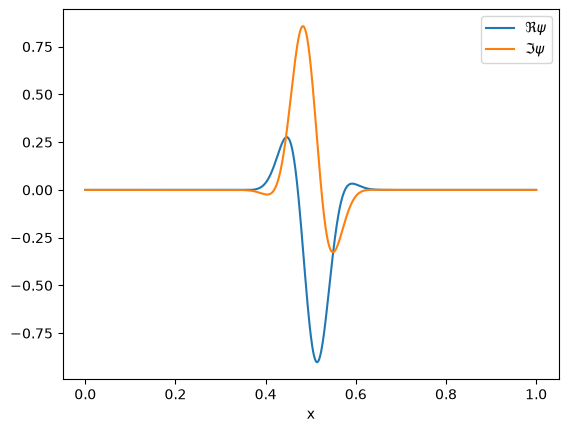

nodes in psi:        31
nodes in Re(psi):    31
conj flips the sign: 6.60e-17


In [4]:
u = psi.real()
v = psi.imag()

x_vec = np.linspace(0, 1, 1000)
plt.plot(x_vec, [u([x]) for x in x_vec], label=r"$\Re \psi$")
plt.plot(x_vec, [v([x]) for x in x_vec], label=r"$\Im \psi$")
plt.xlabel("x")
plt.legend()
plt.show()

print(f"nodes in psi:        {psi.nNodes()}")
print(f"nodes in Re(psi):    {u.nNodes()}")
print(f"conj flips the sign: {(psi.conj().imag() + v).norm():.2e}")

## Arithmetic

Addition, subtraction, scalar multiplication and tree products work as they do
for real trees, and complex scalars are accepted. A real tree mixed into a
complex expression is promoted, so `psi + u` is a `ComplexFunctionTree`.

In [5]:
print(type(psi + u).__name__)          # real operand promoted
print(type(1j * psi).__name__)         # complex scalar
print(type(u * psi).__name__)          # mixed product

# psi = Re(psi) + i Im(psi), to projection accuracy
residual = psi - (u + 1j * v)
print(f"reconstruction residual: {residual.norm():.2e}")

ComplexFunctionTree
ComplexFunctionTree
ComplexFunctionTree


reconstruction residual: 0.00e+00


## Inner products

`dot` conjugates its first argument, so `dot(psi, psi)` is real and equals
`psi.squaredNorm()`. The real `dot` has nothing to conjugate.

In [6]:
print(f"dot(psi, psi)     = {vp1.dot(psi, psi):.10f}")
print(f"psi.squaredNorm() = {psi.squaredNorm():.10f}")

# ... and it is antilinear in the first slot
print(f"dot(1j*psi, psi)  = {vp1.dot(1j * psi, psi):.10f}")

dot(psi, psi)     = 0.0708981540-0.0000000000j
psi.squaredNorm() = 0.0708981540
dot(1j*psi, psi)  = -0.0000000000-0.0708981540j


## Densities

The density $|\psi|^2$ is `square` with `conjugate=True`. The result is real
valued but still lives in a complex tree, so take `real()` to drop the
round-off sized imaginary part. Its integral is the squared norm.

residual imaginary part: 1.13e-18
integral of |psi|^2:     0.0708981540
psi.squaredNorm():       0.0708981540


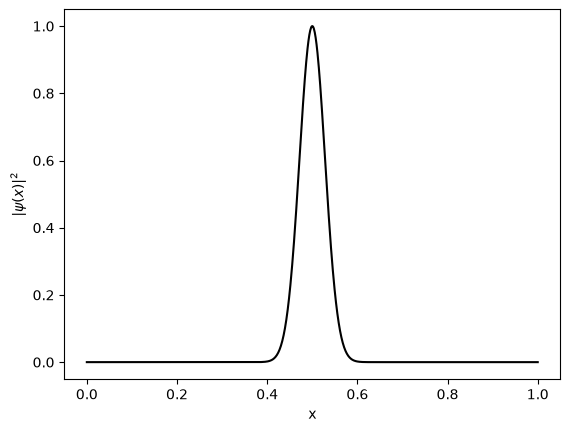

In [7]:
rho = vp1.ComplexFunctionTree(mra)
vp1.advanced.square(prec=precision, out=rho, inp=psi, conjugate=True)

density = rho.real()
print(f"residual imaginary part: {rho.imag().norm():.2e}")
print(f"integral of |psi|^2:     {density.integrate():.10f}")
print(f"psi.squaredNorm():       {psi.squaredNorm():.10f}")

plt.plot(x_vec, [density([x]) for x in x_vec], color="black")
plt.xlabel("x")
plt.ylabel(r"$|\psi(x)|^2$")
plt.show()

## Real operators on complex functions

Most MRCPP kernels are real: the identity, Poisson, Helmholtz and the
derivatives. They apply to a complex tree without any special handling, since
MRCPP contracts the real kernel against both parts.

`iscomplex()` tells us which kind of expansion an operator carries.

In [8]:
Dx = vp1.ABGVDerivative(mra, 0.0, 0.0)
print(f"derivative operator is complex: {Dx.iscomplex()}")

d_psi = vp1.ComplexFunctionTree(mra)
vp1.advanced.apply(out=d_psi, oper=Dx, inp=psi, dir=0)

# d/dx psi ~ i k psi where the envelope is flat, so the derivative is
# dominated by its imaginary part near the centre.
print(f"|Re d_psi| = {d_psi.real().norm():.4f}")
print(f"|Im d_psi| = {d_psi.imag().norm():.4f}")

derivative operator is complex: False
|Re d_psi| = 6.5869
|Im d_psi| = 6.1414


## A complex operator: free particle evolution

`TimeEvolutionOperator` is the exception. It is the free particle Schrodinger
semigroup

\begin{equation*}
    U(t) = \exp \left( i t \partial_x^2 \right)
\end{equation*}

and its kernel is complex, so one operator tree carries the whole
$\cos + i \sin$ coefficient. It cannot be applied to a real tree, and VAMPyR
promotes a real input rather than letting MRCPP refuse it.

The operator is built adaptively by default. Passing a `finest_scale` builds it
on a uniform operator grid instead.

time evolution operator is complex: True


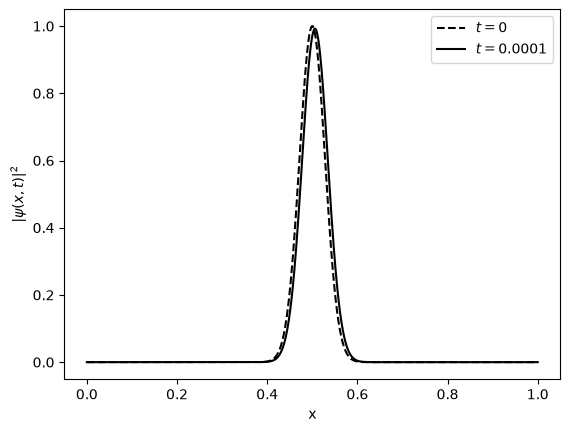

norm at t=0: 0.2662670728
norm at t>0: 0.2662670727


In [9]:
t = 1.0e-4
U = vp1.TimeEvolutionOperator(mra, precision, t)
print(f"time evolution operator is complex: {U.iscomplex()}")

psi_t = U(psi)

plt.plot(x_vec, [density([x]) for x in x_vec], "--", color="black", label=r"$t = 0$")
rho_t = vp1.ComplexFunctionTree(mra)
vp1.advanced.square(prec=precision, out=rho_t, inp=psi_t, conjugate=True)
plt.plot(x_vec, [rho_t.real()([x]) for x in x_vec], color="black", label=f"$t = {t}$")
plt.xlabel("x")
plt.ylabel(r"$|\psi(x, t)|^2$")
plt.legend()
plt.show()

# the semigroup is unitary
print(f"norm at t=0: {psi.norm():.10f}")
print(f"norm at t>0: {psi_t.norm():.10f}")

The packet spreads and drifts: the $e^{ikx}$ factor gives it a group velocity
and the Gaussian envelope disperses. We can compare against the analytic free
particle solution.

In [10]:
def analytic(x, t):
    s = 2 * sigma**2
    denom = s + 4j * t
    return (np.sqrt(s / denom)
            * np.exp(-((x - x0 - 2 * k * t)**2) / denom)
            * np.exp(1j * k * x - 1j * k**2 * t))

exact = Pc(lambda r: analytic(r[0], t))
print(f"relative error vs analytic solution: {(psi_t - exact).norm() / exact.norm():.2e}")

relative error vs analytic solution: 4.57e-07
